In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("flood.csv")
print(df.head())

Saving flood.csv to flood.csv
   S.No  Rainfall (mm)  River Level (m)  Humidity (%)  Temperature (°C)  \
0     1            250              8.5            92                27   
1     2            120              4.2            70                33   
2     3            300              9.8            95                25   
3     4            180              6.5            80                30   
4     5            275              8.9            91                26   

   Soil Moisture (%)  Wind Speed (km/h)  Flood (Target)  
0                 85                 18               1  
1                 45                 12               0  
2                 90                 20               1  
3                 65                 15               0  
4                 88                 17               1  


In [3]:
df.isnull().sum()

,0
S.No,0
Rainfall (mm),0
River Level (m),0
Humidity (%),0
Temperature (°C),0
Soil Moisture (%),0
Wind Speed (km/h),0
Flood (Target),0


In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No               20 non-null     int64  
 1   Rainfall (mm)      20 non-null     int64  
 2   River Level (m)    20 non-null     float64
 3   Humidity (%)       20 non-null     int64  
 4   Temperature (°C)   20 non-null     int64  
 5   Soil Moisture (%)  20 non-null     int64  
 6   Wind Speed (km/h)  20 non-null     int64  
 7   Flood (Target)     20 non-null     int64  
dtypes: float64(1), int64(7)
memory usage: 1.4 KB


In [8]:
df.describe()

,S.No,Rainfall (mm),River Level (m),Humidity (%),Temperature (°C),Soil Moisture (%),Wind Speed (km/h),Flood (Target)
count,20.00000,20.000000,20.000000,20.000000,20.00000,20.00000,20.00000,20.000000
mean,10.50000,204.750000,6.970000,81.850000,29.25000,68.10000,16.00000,0.500000
std,5.91608,77.722093,2.292344,11.766478,3.76794,20.53982,4.02623,0.512989
min,1.00000,90.000000,3.500000,60.000000,24.00000,35.00000,10.00000,0.000000
25%,5.75000,137.500000,4.950000,71.750000,26.00000,49.50000,12.75000,0.000000
50%,10.50000,200.000000,7.150000,84.000000,29.00000,71.50000,15.50000,0.500000
75%,15.25000,276.250000,8.925000,92.000000,32.25000,87.25000,19.25000,1.000000
max,20.00000,320.000000,10.200000,97.000000,36.00000,93.00000,23.00000,1.000000


In [10]:
print(np.mean(df["Rainfall (mm)"]))

204.75


In [13]:
print(np.max(df["River Level (m)"]))

10.2


In [14]:
df.corr(numeric_only=True)

,S.No,Rainfall (mm),River Level (m),Humidity (%),Temperature (°C),Soil Moisture (%),Wind Speed (km/h),Flood (Target)
S.No,1.000000,-0.060952,-0.074901,-0.083546,0.064929,-0.091390,0.022096,-0.086711
Rainfall (mm),-0.060952,1.000000,0.997105,0.985811,-0.990036,0.988426,0.978032,0.920742
River Level (m),-0.074901,0.997105,1.000000,0.991076,-0.992317,0.994363,0.975134,0.917513
Humidity (%),-0.083546,0.985811,0.991076,1.000000,-0.990358,0.995068,0.966542,0.919908
Temperature (°C),0.064929,-0.990036,-0.992317,-0.990358,1.000000,-0.989144,-0.978347,-0.884948
Soil Moisture (%),-0.091390,0.988426,0.994363,0.995068,-0.989144,1.000000,0.962920,0.924088
Wind Speed (km/h),0.022096,0.978032,0.975134,0.966542,-0.978347,0.962920,1.000000,0.866400
Flood (Target),-0.086711,0.920742,0.917513,0.919908,-0.884948,0.924088,0.866400,1.000000


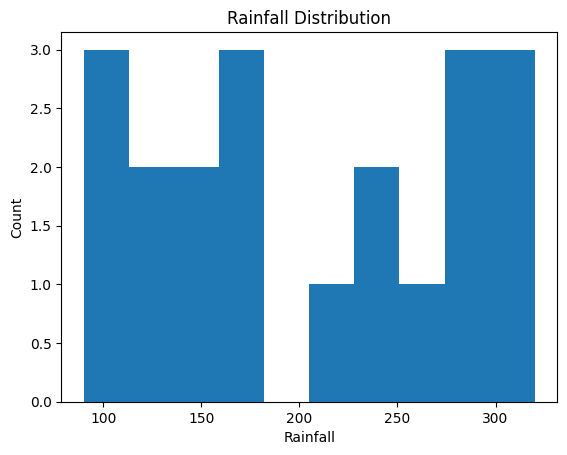

In [16]:
plt.hist(df["Rainfall (mm)"])
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Count")
plt.show()

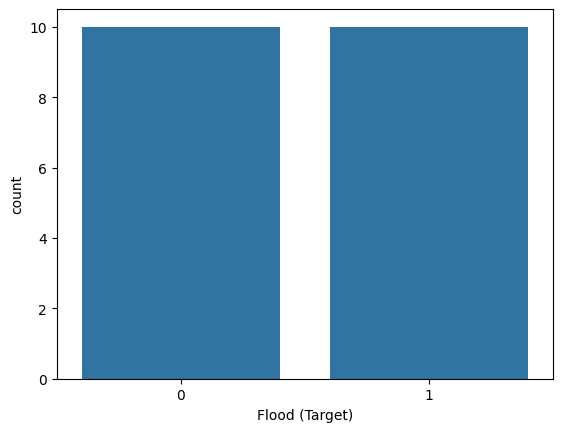

In [17]:
sns.countplot(x="Flood (Target)", data=df)
plt.show()

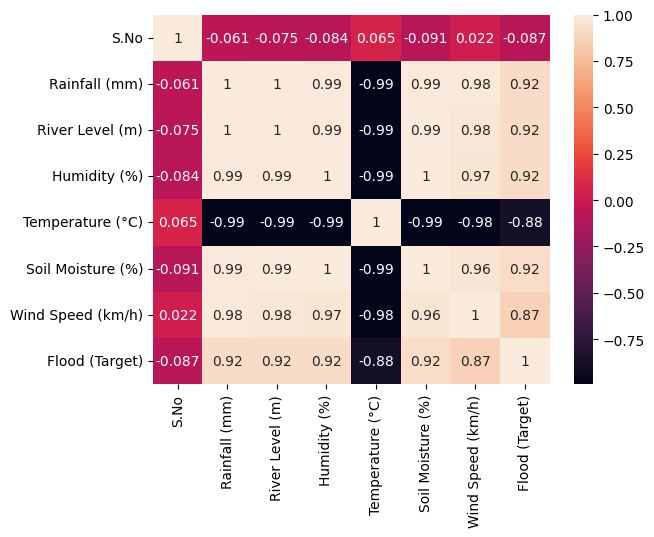

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

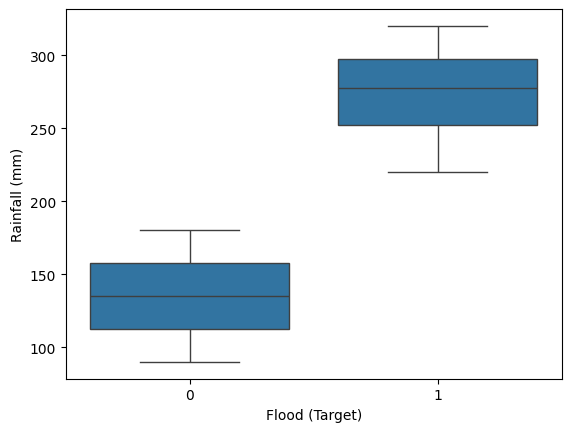

In [20]:
sns.boxplot(x="Flood (Target)", y="Rainfall (mm)", data=df)
plt.show()

In [22]:
X = df.drop("Flood (Target)", axis=1)

y = df["Flood (Target)"]

In [23]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [24]:
model=RandomForestClassifier()

model.fit(X_train,y_train)

RandomForestClassifier()

In [25]:
prediction=model.predict(X_test)

In [26]:
accuracy_score(y_test,prediction)

1.0

In [27]:
confusion_matrix(y_test,prediction)

array([[3, 0],
       [0, 1]])

In [28]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [33]:
new_data = pd.DataFrame([[0, 250, 9.0, 88, 27, 80, 16.0]],
                       columns=['S.No', 'Rainfall (mm)', 'River Level (m)', 'Humidity (%)', 'Temperature (°C)', 'Soil Moisture (%)', 'Wind Speed (km/h)'])

model.predict(new_data)

array([1])

In [35]:
rainfall = new_data['Rainfall (mm)'].iloc[0]
if rainfall > 250:
    print("High Risk")

elif rainfall > 150:
    print("Medium Risk")

else:
    print("Low Risk")

Low Risk
